# 04 · LightGBM e comparação com o scorecard

O scorecard do [notebook 03](03_logistic_scorecard.ipynb) é transparente, mas tem limitações: trata cada variável de forma independente e só enxerga o risco em faixas. Um gradient boosting consegue capturar interações (por exemplo, limite estourado pesa diferente para um jovem e para um aposentado) e usar os valores contínuos direto, sem agrupar.

A pergunta deste notebook é se esse ganho existe nesta base e se ele compensa a perda de simplicidade.

Três cuidados:

- **Todas as 15 variáveis entram como estão.** O LightGBM lida sozinho com faltantes, escalas e caudas longas, então não precisa de WoE.
- **Restrições de monotonicidade.** Onde a regra de negócio é clara (mais atraso nunca pode diminuir o risco, mais idade nunca pode aumentá-lo), eu obrigo o modelo a respeitá-la. Isso evita que ele aprenda um ruído do tipo "3 atrasos é melhor que 2", que seria impossível de justificar para um cliente ou para um regulador.
- **A validação continua limpa.** Hiperparâmetros e número de árvores são escolhidos por validação cruzada **dentro do treino**, para que a comparação com a logística na validação seja justa.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, roc_curve

from credit_scoring.data import PROCESSED_DIR, ROOT, TARGET
from credit_scoring.features import FEATURES
from credit_scoring.gbm import MONOTONE, cv_best_rounds, fit, grid_search, make_params
from credit_scoring.metrics import calibration_table, evaluate
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import update_metrics
from credit_scoring.scorecard import SCORECARD_FEATURES

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]

logistic = joblib.load(ROOT / "models" / "logistic_woe.joblib")
p_val_logistic = logistic.predict_proba(val[SCORECARD_FEATURES])[:, 1]

## 1. Restrições de monotonicidade

As variáveis que ficam livres são as que têm forma de U ou uma exceção conhecida, como o "uso zero" do rotativo, que vimos ser mais arriscado do que o uso baixo.

In [2]:
pd.DataFrame({
    "restrição": [{1: "risco só sobe", -1: "risco só desce"}.get(MONOTONE.get(f), "livre") for f in FEATURES]
}, index=FEATURES)

,restrição
revolving_util,livre
age,risco só desce
late_30_59,risco só sobe
late_60_89,risco só sobe
late_90,risco só sobe
debt_ratio,risco só sobe
monthly_income,risco só desce
open_credit_lines,livre
real_estate_loans,livre
dependents,livre


## 2. Escolha de hiperparâmetros

Uma busca pequena, de propósito. Com 105 mil linhas e 15 variáveis, o que mais importa é o tamanho das árvores (`num_leaves`) e o mínimo de clientes por folha (`min_child_samples`), que controla o sobreajuste. Para cada combinação, com e sem restrições, a validação cruzada de 5 partes no treino escolhe o número de árvores por *early stopping*.

In [3]:
grid = {"num_leaves": [7, 15, 31], "min_child_samples": [100, 400]}
search = grid_search(X_train, y_train, grid)
search

,monotone,num_leaves,min_child_samples,n_arvores,auc_cv
0,False,15,400,268,0.8642
1,False,15,100,302,0.8641
2,True,15,400,242,0.8640
3,True,31,400,191,0.8640
4,False,7,100,404,0.8640
5,True,31,100,177,0.8640
6,False,7,400,397,0.8640
7,False,31,400,185,0.8638
8,True,15,100,312,0.8637
9,False,31,100,189,0.8637


As diferenças de AUC entre as combinações aparecem só na quarta casa decimal, ou seja, o modelo é pouco sensível a esses parâmetros nesta base. O resultado mais importante é outro: **as restrições de monotonicidade praticamente não custam desempenho**. Então não há motivo para abrir mão delas, e fico com a melhor configuração restrita.

In [4]:
best = search[search["monotone"]].iloc[0]
best_overrides = {k: int(best[k]) for k in grid}
params = make_params(FEATURES, monotone=True, **best_overrides)
n_trees = int(best["n_arvores"])
print(f"configuração escolhida: {best_overrides}, {n_trees} árvores")

booster = fit(params, X_train, y_train, n_trees)
p_train = booster.predict(X_train)
p_val = booster.predict(X_val)

configuração escolhida: {'num_leaves': 15, 'min_child_samples': 400}, 242 árvores


## 3. LightGBM vs scorecard

In [5]:
comparison = pd.DataFrame({
    "scorecard (logística + WoE)": {**evaluate(y_val, p_val_logistic), "brier": brier_score_loss(y_val, p_val_logistic)},
    "LightGBM": {**evaluate(y_val, p_val), "brier": brier_score_loss(y_val, p_val)},
}).T
comparison.loc["diferença"] = comparison.iloc[1] - comparison.iloc[0]
print(f"LightGBM treino: {evaluate(y_train, p_train)}")
comparison

LightGBM treino: {'auc': 0.8725983943904784, 'gini': 0.7451967887809567, 'ks': 0.5889113120671998}


,auc,gini,ks,brier
scorecard (logística + WoE),0.8614,0.7227,0.5649,0.0503
LightGBM,0.8707,0.7415,0.5898,0.0487
diferença,0.0094,0.0188,0.0249,-0.0017


O LightGBM ganha nas três métricas de separação. O ganho é real, mas modesto, o que é comum em dados de crédito tabulares com poucas variáveis: a maior parte do sinal está em relações simples (atrasou ou não, limite estourado ou não), que a regressão logística já pega bem.

Uma pergunta que vale fazer: de onde vem esse ganho? Das variáveis a mais que o LightGBM recebeu ou da forma mais flexível de modelar? Para separar as duas coisas, treino o mesmo LightGBM só com as 7 variáveis do scorecard.

In [6]:
X_train_7, X_val_7 = train[SCORECARD_FEATURES], val[SCORECARD_FEATURES]
params_7 = make_params(SCORECARD_FEATURES, monotone=True, **best_overrides)
rounds_7, _ = cv_best_rounds(params_7, X_train_7, y_train)
p_val_7 = fit(params_7, X_train_7, y_train, rounds_7).predict(X_val_7)

ablation = pd.DataFrame({
    "scorecard, 7 variáveis": evaluate(y_val, p_val_logistic),
    "LightGBM, mesmas 7 variáveis": evaluate(y_val, p_val_7),
    "LightGBM, 15 variáveis": evaluate(y_val, p_val),
}).T
ablation

,auc,gini,ks
"scorecard, 7 variáveis",0.8614,0.7227,0.5649
"LightGBM, mesmas 7 variáveis",0.8688,0.7376,0.5838
"LightGBM, 15 variáveis",0.8707,0.7415,0.5898


A maior parte do ganho aparece já com as mesmas 7 variáveis. Ou seja, vem da flexibilidade do modelo (valores contínuos em vez de faixas, interações entre variáveis), e não das variáveis extras. Elas acrescentam um pouco, mas bem menos.

## 4. O ganho em linguagem de negócio

AUC é abstrato. Uma forma mais concreta de comparar: se a cooperativa aprovar a mesma proporção de propostas com os dois modelos, quantos inadimplentes cada um deixa passar?

In [7]:
def bad_rate_at_approval(y, p, approval_rate):
    # aprova as propostas com menor probabilidade de default
    approved = p <= np.quantile(p, approval_rate)
    return y[approved].mean(), int(y[approved].sum())

rows = []
for rate in [0.7, 0.8, 0.9]:
    br_log, bad_log = bad_rate_at_approval(y_val.values, p_val_logistic, rate)
    br_gbm, bad_gbm = bad_rate_at_approval(y_val.values, p_val, rate)
    rows.append({"aprovação": f"{rate:.0%}", "default aprovados · scorecard": br_log, "default aprovados · LightGBM": br_gbm,
                 "inadimplentes aprovados · scorecard": bad_log, "inadimplentes aprovados · LightGBM": bad_gbm,
                 "redução": 1 - bad_gbm / bad_log})
at_approval = pd.DataFrame(rows).set_index("aprovação")
at_approval.style.format({c: "{:.2%}" for c in at_approval.columns if "default" in c} | {"redução": "{:.1%}"})

,default aprovados · scorecard,default aprovados · LightGBM,inadimplentes aprovados · scorecard,inadimplentes aprovados · LightGBM,redução
aprovação,,,,,
70%,1.72%,1.56%,271,245,9.6%
80%,2.41%,2.24%,433,404,6.7%
90%,3.42%,3.32%,692,672,2.9%


Com a mesma taxa de aprovação, o LightGBM deixa passar menos inadimplentes, e a vantagem é maior quanto mais restritiva é a política. Numa carteira real isso vira dinheiro, e é exatamente essa conta que o notebook de cutoff vai fazer com valores de lucro e perda.

## 5. As probabilidades são confiáveis?

A simulação financeira usa a probabilidade de default diretamente: perda esperada = probabilidade × valor exposto. Então não basta o modelo ordenar bem os clientes, a probabilidade também precisa bater com a realidade. Para conferir, divido a validação em 10 faixas de probabilidade prevista e comparo a média prevista com a taxa de default observada em cada uma.

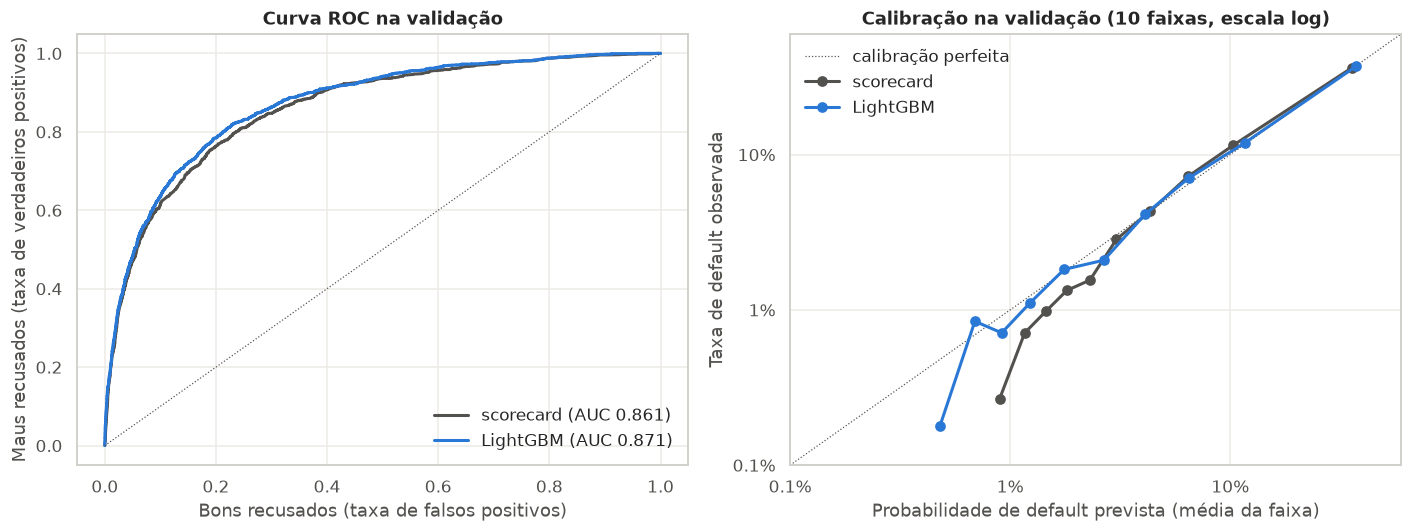

scorecard                 LightGBM                
       prevista observada     n prevista observada     n
faixa                                                   
1        0.0089    0.0027  2250   0.0048    0.0018  2250
2        0.0116    0.0071  2250   0.0069    0.0084  2250
3        0.0145    0.0098  2250   0.0091    0.0071  2250
4        0.0181    0.0133  2250   0.0123    0.0111  2250
5        0.0230    0.0156  2250   0.0176    0.0182  2250
6        0.0304    0.0284  2250   0.0267    0.0209  2250
7        0.0432    0.0431  2250   0.0411    0.0413  2250
8        0.0645    0.0724  2250   0.0649    0.0707  2250
9        0.1035    0.1151  2250   0.1166    0.1191  2250
10       0.3559    0.3609  2250   0.3726    0.3698  2250

In [8]:
cal_log = calibration_table(y_val, p_val_logistic)
cal_gbm = calibration_table(y_val, p_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name, p, color in [("scorecard", p_val_logistic, GRAY), ("LightGBM", p_val, BLUE)]:
    fpr, tpr, _ = roc_curve(y_val, p)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {evaluate(y_val, p)['auc']:.3f})")
ax1.plot([0, 1], [0, 1], color=GRAY, lw=0.8, ls=":")
ax1.set_xlabel("Bons recusados (taxa de falsos positivos)")
ax1.set_ylabel("Maus recusados (taxa de verdadeiros positivos)")
ax1.set_title("Curva ROC na validação")
ax1.legend(loc="lower right", frameon=False)

lims = [1e-3, 0.6]
ax2.plot(lims, lims, color=GRAY, lw=0.8, ls=":", label="calibração perfeita")
ax2.plot(cal_log["prevista"], cal_log["observada"], "o-", color=GRAY, lw=2, ms=6, label="scorecard")
ax2.plot(cal_gbm["prevista"], cal_gbm["observada"], "o-", color=BLUE, lw=2, ms=6, label="LightGBM")
ax2.set_xlabel("Probabilidade de default prevista (média da faixa)")
ax2.set_ylabel("Taxa de default observada")
ax2.set_title("Calibração na validação (10 faixas, escala log)")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(lims)
ax2.set_ylim(lims)
for axis in (ax2.xaxis, ax2.yaxis):
    axis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}" if v < 0.01 else f"{v:.0%}"))
ax2.legend(loc="upper left", frameon=False)
fig.tight_layout()
savefig(fig, "lgbm_roc_calibration")
plt.show()

display(pd.concat({"scorecard": cal_log, "LightGBM": cal_gbm}, axis=1))

Usei escala log porque a maioria dos clientes está na região de risco baixo, que numa escala linear fica espremida num canto.

Nas faixas de risco alto, os dois modelos acertam bem: prevista e observada praticamente coincidem. A diferença está no risco baixo. Ali o scorecard **superestima** o risco: nas faixas mais seguras ele prevê um default bem maior do que o observado. Faz sentido: com faixas de WoE, o cliente mais seguro possível ainda é tratado como a média da sua faixa, então há um "piso" de risco. O LightGBM, que usa os valores contínuos, chega mais perto da realidade nessa região.

Isso importa para o próximo passo: um modelo que exagera o risco dos bons clientes leva a um cutoff conservador demais, que recusa gente que pagaria. O fato de nenhum dos dois ter sido treinado com oversampling ou pesos de classe ajuda: as probabilidades já saem na escala real da base.

## 6. O que o LightGBM está usando

Uma primeira olhada pela importância por ganho (quanto cada variável reduziu o erro somando todas as árvores). É uma medida grosseira. A explicação de verdade, por cliente e com direção do efeito, vem com o SHAP no notebook de interpretabilidade.

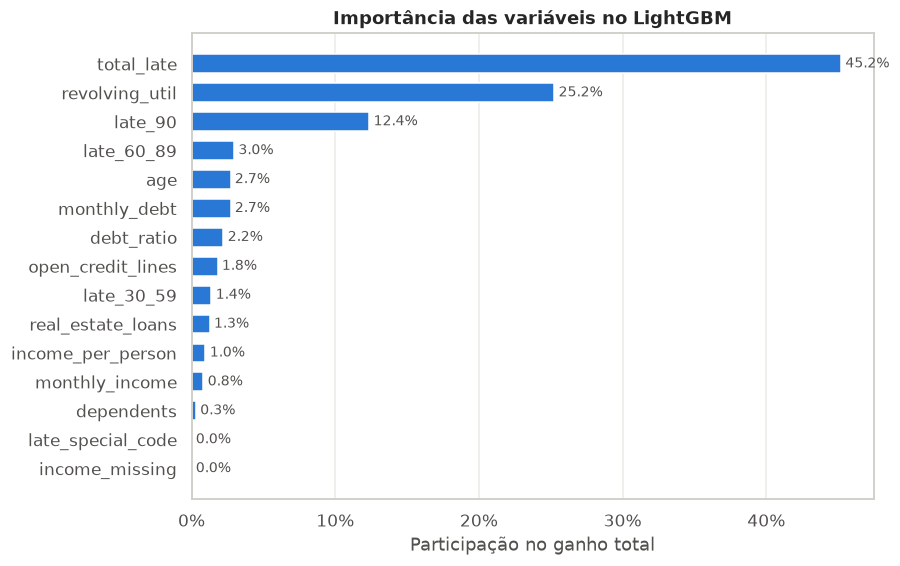

In [9]:
importance = pd.Series(booster.feature_importance("gain"), index=FEATURES)
importance = (importance / importance.sum()).sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.65)
for i, v in enumerate(importance.values):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=9, color=GRAY)
ax.set_xlabel("Participação no ganho total")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Importância das variáveis no LightGBM")
ax.grid(axis="y", visible=False)
savefig(fig, "lgbm_importance")
plt.show()

O ranking bate com o que o IV mostrava no notebook 02: utilização do rotativo e histórico de atrasos na frente, seguidos por idade e pelas variáveis de renda e dívida. Não aparece nenhuma variável "surpresa" dominando o modelo, o que seria um sinal de alerta para vazamento.

As flags `late_special_code` e `income_missing` ficaram com importância zero. Para o LightGBM elas são redundantes, porque ele já recebe os `NaN` nas colunas originais e aprende sozinho para que lado mandar os faltantes. Deixei as duas no modelo por serem inofensivas, mas numa versão de produção elas poderiam sair.

## 7. Qual modelo usar?

O LightGBM separa melhor os clientes, tem probabilidades mais fiéis à realidade justamente na faixa de risco baixo e respeita as regras de negócio mais importantes graças às restrições. Em contrapartida, não vira uma tabela de pontos, então a explicação de cada decisão precisa de uma ferramenta a mais (o SHAP).

Minha escolha é seguir com o **LightGBM como modelo de decisão** e manter o **scorecard como referência** (*challenger*). O ganho aparece em inadimplentes evitados, e a exigência de explicar as decisões, que vem da LGPD, dá para cumprir com SHAP e reason codes, que é justamente o próximo passo. O scorecard continua útil como comparação e como plano B se a área de risco preferir um modelo totalmente em tabela.

## 8. Salvando

In [10]:
booster.save_model(str(ROOT / "models" / "lightgbm.txt"))

update_metrics("lightgbm", {
    "features": FEATURES,
    "params": {**best_overrides, "n_trees": n_trees, "learning_rate": params["learning_rate"], "monotone": True},
    "train": {k: round(v, 4) for k, v in evaluate(y_train, p_train).items()},
    "val": {k: round(v, 4) for k, v in evaluate(y_val, p_val).items()},
    "val_brier": round(float(brier_score_loss(y_val, p_val)), 5),
    "val_same_7_features": {k: round(v, 4) for k, v in evaluate(y_val, p_val_7).items()},
})["lightgbm"]

{'features': ['revolving_util',
  'age',
  'late_30_59',
  'late_60_89',
  'late_90',
  'debt_ratio',
  'monthly_income',
  'open_credit_lines',
  'real_estate_loans',
  'dependents',
  'income_missing',
  'late_special_code',
  'total_late',
  'monthly_debt',
  'income_per_person'],
 'params': {'num_leaves': 15,
  'min_child_samples': 400,
  'n_trees': 242,
  'learning_rate': 0.03,
  'monotone': True},
 'train': {'auc': 0.8726, 'gini': 0.7452, 'ks': 0.5889},
 'val': {'auc': 0.8707, 'gini': 0.7415, 'ks': 0.5898},
 'val_brier': 0.04867,
 'val_same_7_features': {'auc': 0.8688, 'gini': 0.7376, 'ks': 0.5838}}